# Project 2b -- Bayesian Updates Dashboard: Bernoulli Data

We model a sequence of binary outcomes $X_1, \dots, X_n \overset{iid}{\sim} \text{Bernoulli}(p)$
-- for example, $X_t = 1$ if a stock's daily return is positive and $X_t = 0$ otherwise -- and
use Bayesian updating to learn about the unknown success probability $p$.

**Prior:** $p \sim \text{Beta}(a, b)$. Default $a = b = 1$, i.e. $\text{Beta}(1,1) = \text{Uniform}(0,1)$
(uninformative prior).

**Likelihood:** for data with $s = \sum_{i=1}^n x_i$ successes out of $n$ trials,
$$L(p \mid \text{data}) \propto p^{s}(1-p)^{n-s}$$

**Posterior (Beta-Bernoulli conjugacy):**
$$p \mid \text{data} \;\sim\; \text{Beta}(a', b'), \qquad a' = a + s, \quad b' = b + (n - s)$$

**Point estimates from the posterior $\text{Beta}(a', b')$:**

- MAP (posterior mode):
$$\hat{p}_{\text{MAP}} = \frac{a' - 1}{a' + b' - 2} \qquad (\text{for } a', b' > 1)$$

- Bayes estimate (posterior mean):
$$\hat{p}_{\text{Bayes}} = \mathbb{E}[p \mid \text{data}] = \frac{a'}{a' + b'}$$

In [1]:
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt

In [2]:
def posterior_params(a, b, data):
    """Beta(a, b) prior + Bernoulli data -> Beta(a', b') posterior parameters."""
    data = np.asarray(data)
    s = data.sum()
    n = data.size
    return a + s, b + (n - s)


def map_estimate(a, b):
    """Posterior mode of Beta(a, b). NaN where the mode is not unique (a, b <= 1)."""
    if a > 1 and b > 1:
        return (a - 1) / (a + b - 2)
    elif a <= 1 and b > 1:
        return 0.0
    elif a > 1 and b <= 1:
        return 1.0
    else:
        return np.nan


def bayes_estimate(a, b):
    """Posterior mean of Beta(a, b)."""
    return a / (a + b)


def parse_data(data_str):
    """Parse a string of 0s and 1s (e.g. '1100101100') into a numpy array."""
    return np.array([int(ch) for ch in data_str.strip() if ch in "01"])

In [3]:
def bayes_update_plot(a, b, data):
    a_post, b_post = posterior_params(a, b, data)
    map_p = map_estimate(a_post, b_post)
    bayes_p = bayes_estimate(a_post, b_post)

    x = np.linspace(0, 1, 500)
    prior_pdf = beta.pdf(x, a, b)
    post_pdf = beta.pdf(x, a_post, b_post)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x, prior_pdf, label=f"Prior: Beta({a:.2f}, {b:.2f})", color="tab:blue")
    ax.plot(x, post_pdf, label=f"Posterior: Beta({a_post:.2f}, {b_post:.2f})", color="tab:orange")
    if not np.isnan(map_p):
        ax.axvline(map_p, color="tab:green", linestyle="--", label=f"MAP estimate = {map_p:.3f}")
    ax.axvline(bayes_p, color="tab:red", linestyle=":", label=f"Bayes estimate = {bayes_p:.3f}")
    ax.set_xlabel("p")
    ax.set_ylabel("Density")
    ax.set_title(f"Bayesian Update for Bernoulli(p) -- n={data.size}, s={data.sum()} successes")
    ax.legend()
    plt.show()

    print(f"n = {data.size}, successes (1s) = {data.sum()}")
    print(f"Posterior: Beta({a_post:.3f}, {b_post:.3f})")
    print(f"MAP estimate:   p_hat_MAP   = {map_p:.4f}")
    print(f"Bayes estimate: p_hat_Bayes = {bayes_p:.4f}")

## Interactive Dashboard

Running the cell below prompts for the prior parameters $a$, $b$ and the observed data (a
string of 0s and 1s, e.g. `1100101100`). Press Enter to accept the default shown in brackets.
The plot then shows the Prior and Posterior PDFs and the MAP/Bayes estimates for $p$.

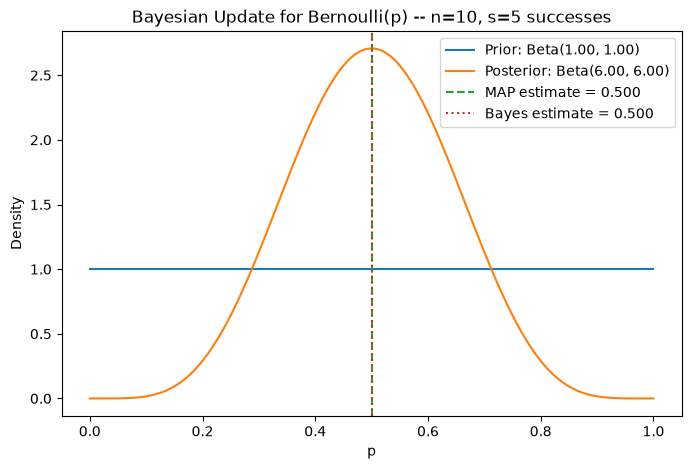

n = 10, successes (1s) = 5
Posterior: Beta(6.000, 6.000)
MAP estimate:   p_hat_MAP   = 0.5000
Bayes estimate: p_hat_Bayes = 0.5000


In [4]:
def run_dashboard():
    a = float(input("Prior parameter a [1]: ") or 1)
    b = float(input("Prior parameter b [1]: ") or 1)
    data_str = input("Data (0s and 1s) [1100101100]: ") or "1100101100"
    bayes_update_plot(a, b, parse_data(data_str))


run_dashboard()

## Example: Is AAPL's Daily Return Positive?

Treat each trading day as a Bernoulli trial: $X_t = 1$ if AAPL's daily log return is positive,
$X_t = 0$ otherwise. Starting from the uninformative prior $\text{Beta}(1,1)$, update on the
full history of sign data.

[*********************100%***********************]  1 of 1 completed


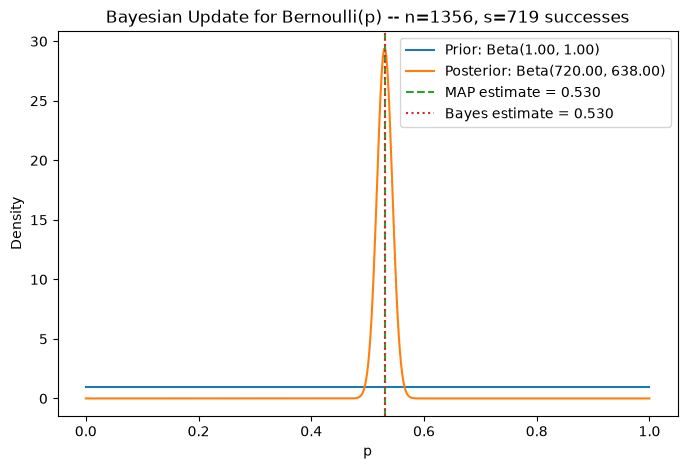

n = 1356, successes (1s) = 719
Posterior: Beta(720.000, 638.000)
MAP estimate:   p_hat_MAP   = 0.5302
Bayes estimate: p_hat_Bayes = 0.5302


In [5]:
import yfinance as yf

close = yf.download("AAPL", start="2021-01-01", end="2026-06-01")["Close"]
returns = np.log(close / close.shift(1)).dropna()
sign_data = (returns["AAPL"] > 0).astype(int).values

bayes_update_plot(1, 1, sign_data)